RESULTADO DO TREINAMENTO

Episódios: 5000
Vitórias: 4964
Taxa de sucesso: 99.28%
Recompensa média: 96.28

POLÍTICA APRENDIDA

 →  →  O  P 
 ↑  ↑  W  ↑ 
 ↑  P  ↑  ↑ 
 P  ↑  ↑  ↑ 

MAPA FINAL

[S] [*] [O] [P] 
[ ] [ ] [W] [ ] 
[ ] [P] [ ] [ ] 
[P] [ ] [ ] [ ] 

MELHOR CAMINHO ENCONTRADO:

(0, 0) -> (0, 1) -> (0, 2)

STATUS: OURO ENCONTRADO
Quantidade de passos: 2


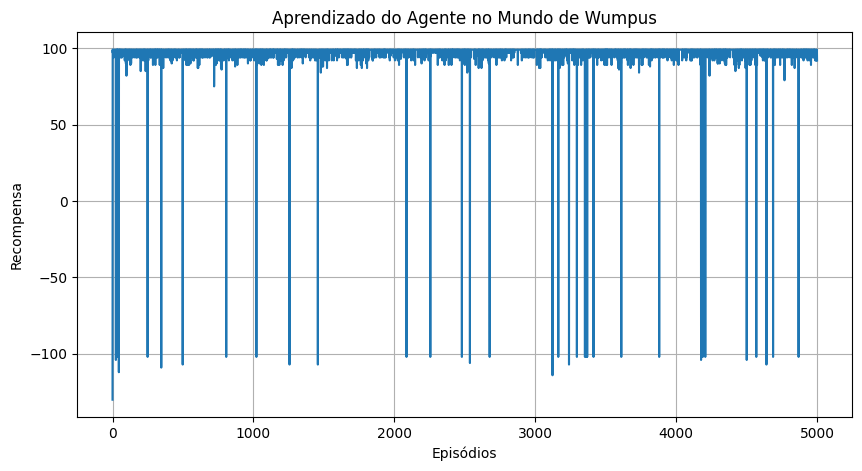

In [5]:
import random
import matplotlib.pyplot as plt

TAM = 4

INICIO = (0, 0)
OURO = (0, 2)
WUMPUS = (1, 2)
POCOS = [(3, 0), (2, 1), (0, 3)]

ACOES = [
    (-1, 0),  # cima
    (1, 0),   # baixo
    (0, -1),  # esquerda
    (0, 1)    # direita
]

NOMES_ACOES = ["↑", "↓", "←", "→"]

# PARÂMETROS Q-LEARNING
ALPHA = 0.1
GAMMA = 0.9
EPSILON = 0.2
EPISODIOS = 5000

# TABELA Q
Q = {}

for i in range(TAM):
    for j in range(TAM):
        Q[(i, j)] = [0.0, 0.0, 0.0, 0.0]


def estado_valido(x, y):
    return 0 <= x < TAM and 0 <= y < TAM


def executar_acao(estado, acao):

    x, y = estado
    dx, dy = ACOES[acao]

    nx = x + dx
    ny = y + dy

    if not estado_valido(nx, ny):
        return estado, -5, False

    novo_estado = (nx, ny)

    # Poço
    if novo_estado in POCOS:
        return novo_estado, -100, True

    # Wumpus
    if novo_estado == WUMPUS:
        return novo_estado, -100, True

    # Ouro
    if novo_estado == OURO:
        return novo_estado, 100, True

    # Movimento normal
    return novo_estado, -1, False


# TREINAMENTO
recompensas = []
vitorias = 0

for episodio in range(EPISODIOS):

    estado = INICIO
    terminou = False
    recompensa_total = 0

    while not terminou:

        # Exploração ou Exploitação
        if random.random() < EPSILON:
            acao = random.randint(0, 3)
        else:
            acao = Q[estado].index(max(Q[estado]))

        proximo_estado, recompensa, terminou = executar_acao(
            estado,
            acao
        )

        melhor_q = max(Q[proximo_estado])

        Q[estado][acao] = Q[estado][acao] + ALPHA * (
            recompensa +
            GAMMA * melhor_q -
            Q[estado][acao]
        )

        recompensa_total += recompensa
        estado = proximo_estado

    recompensas.append(recompensa_total)

    if estado == OURO:
        vitorias += 1


#MELHOR CAMINHO
def obter_melhor_caminho():

    estado = INICIO
    caminho = [estado]
    visitados = set()

    while estado != OURO:

        visitados.add(estado)

        acao = Q[estado].index(max(Q[estado]))

        novo_estado, _, terminou = executar_acao(
            estado,
            acao
        )

        if novo_estado in visitados:
            break

        caminho.append(novo_estado)
        estado = novo_estado

        if terminou:
            break

    return caminho


# MAPA
def mostrar_mapa(caminho):

    print("\nMAPA FINAL\n")

    for i in range(TAM):

        for j in range(TAM):

            pos = (i, j)

            if pos == INICIO:
                simbolo = "S"

            elif pos == OURO:
                simbolo = "O"

            elif pos == WUMPUS:
                simbolo = "W"

            elif pos in POCOS:
                simbolo = "P"

            elif pos in caminho:
                simbolo = "*"

            else:
                simbolo = " "

            print(f"[{simbolo}]", end=" ")

        print()


# POLÍTICA APRENDIDA
def mostrar_politica():

    print("\nPOLÍTICA APRENDIDA\n")

    for i in range(TAM):

        for j in range(TAM):

            estado = (i, j)

            if estado == OURO:
                print(" O ", end="")

            elif estado == WUMPUS:
                print(" W ", end="")

            elif estado in POCOS:
                print(" P ", end="")

            else:
                melhor = Q[estado].index(max(Q[estado]))
                print(f" {NOMES_ACOES[melhor]} ", end="")

        print()


#RESULTADOS
caminho = obter_melhor_caminho()

print("RESULTADO DO TREINAMENTO")

print(f"\nEpisódios: {EPISODIOS}")
print(f"Vitórias: {vitorias}")
print(f"Taxa de sucesso: {(vitorias/EPISODIOS)*100:.2f}%")
print(f"Recompensa média: {sum(recompensas)/len(recompensas):.2f}")

mostrar_politica()

mostrar_mapa(caminho)

print("\nMELHOR CAMINHO ENCONTRADO:\n")

for i, pos in enumerate(caminho):

    print(pos, end="")

    if i < len(caminho) - 1:
        print(" -> ", end="")

print()

if caminho[-1] == OURO:
    print("\nSTATUS: OURO ENCONTRADO")
else:
    print("\nSTATUS: CAMINHO INCOMPLETO")

print(f"Quantidade de passos: {len(caminho)-1}")


# GRÁFICO DE APRENDIZADO
plt.figure(figsize=(10, 5))
plt.plot(recompensas)

plt.title("Aprendizado do Agente no Mundo de Wumpus")
plt.xlabel("Episódios")
plt.ylabel("Recompensa")

plt.grid(True)

plt.show()